In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torchvision import datasets, transforms
import matplotlib.pyplot as plt

mnist_images = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())

class FCNet(nn.Module):
    def __init__(self):
        super(FCNet, self).__init__()
        self.layer1 = nn.Linear(28 * 28, 50)
        self.layer2 = nn.Linear(50, 20)
        self.layer3 = nn.Linear(20, 10)
    def forward(self, img):
        flattened = img.view(-1, 28 * 28)
        activation1 = F.relu(self.layer1(flattened))
        activation2 = F.relu(self.layer2(activation1))
        output = self.layer3(activation2)
        return output

class ConvNet(nn.Module):
    def __init__(self):
        super(ConvNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 5, 5, padding=2)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(5, 10, 5, padding=2)
        self.fc1 = nn.Linear(10 * 7 * 7, 32)
        self.fc2 = nn.Linear(32, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 10 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        x = x.squeeze(1)
        return x

100%|██████████| 9912422/9912422 [00:00<00:00, 74944139.85it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 28881/28881 [00:00<00:00, 59032989.19it/s]

Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw




100%|██████████| 1648877/1648877 [00:00<00:00, 28433546.01it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw



100%|██████████| 4542/4542 [00:00<00:00, 1787439.37it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



In [ ]:
def train(model, data, batch_size=64, lr=0.001, num_iters=1000, print_every=100):
    train_loader = torch.utils.data.DataLoader(data, batch_size=batch_size)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    total_loss = 0
    n = 0

    while True:
        for imgs, labels in iter(train_loader):
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()
            total_loss += loss.item()
            n += 1

            if n % print_every == 0:
                print("Iter %d. Avg.Loss: %f" % (n, total_loss/print_every))
                total_loss = 0
            if n > num_iters:
                return

In [ ]:
fc_model = FCNet()
train(fc_model, mnist_images, num_iters=1000)

Iter 100. Avg.Loss: 1.467430
Iter 200. Avg.Loss: 0.568474
Iter 300. Avg.Loss: 0.444796
Iter 400. Avg.Loss: 0.360211
Iter 500. Avg.Loss: 0.359616
Iter 600. Avg.Loss: 0.318497
Iter 700. Avg.Loss: 0.319435
Iter 800. Avg.Loss: 0.315846
Iter 900. Avg.Loss: 0.257320
Iter 1000. Avg.Loss: 0.221804


In [ ]:
cnn_model = ConvNet()
train(cnn_model, mnist_images, num_iters=1000)

Iter 100. Avg.Loss: 1.256118
Iter 200. Avg.Loss: 0.404067
Iter 300. Avg.Loss: 0.285397
Iter 400. Avg.Loss: 0.199020
Iter 500. Avg.Loss: 0.196022
Iter 600. Avg.Loss: 0.171181
Iter 700. Avg.Loss: 0.158246
Iter 800. Avg.Loss: 0.165186
Iter 900. Avg.Loss: 0.130423
Iter 1000. Avg.Loss: 0.107203


### Targetted Adversarial Attack

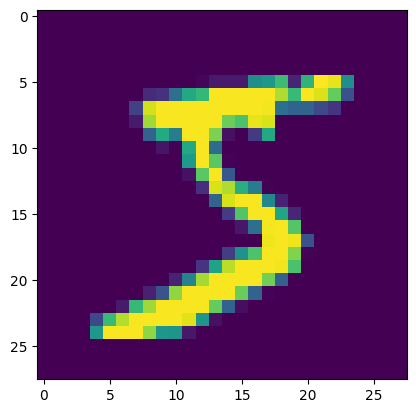

In [ ]:
image = mnist_images[0][0]
target_label = 3
model = fc_model

plt.imshow(image[0])

In [ ]:
noise = torch.randn(1, 28, 28) * 0.01
noise.requires_grad = True

In [ ]:
optimizer = optim.Adam([noise], lr=0.01, weight_decay=1)
criterion = nn.CrossEntropyLoss()

for i in range(1000):
    adv_image = torch.clamp(image + noise, 0, 1)
    out = model(adv_image.unsqueeze(0))
    loss = criterion(out, torch.Tensor([target_label]).long())
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

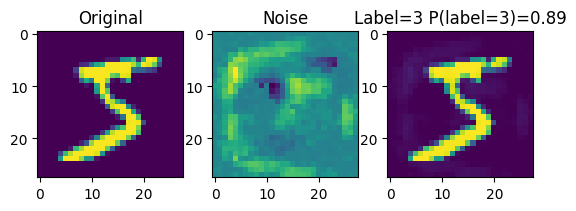

In [ ]:
adv_image = torch.clamp(image + noise, 0, 1)
adv_label = torch.argmax(model(adv_image), dim=1).item()
adv_percent = torch.softmax(model(adv_image), dim=1)[0,target_label].item()

plt.subplot(1, 3, 1)
plt.title("Original")
plt.imshow(image[0])

plt.subplot(1, 3, 2)
plt.title("Noise")
plt.imshow(noise[0].detach().numpy())

plt.subplot(1, 3, 3)
plt.title("Label=%d P(label=%d)=%.2f" % (adv_label, target_label, adv_percent))
plt.imshow(adv_image.detach().numpy()[0])

In [ ]:
def create_adversarial_example(model, image, target_label):
    noise = torch.randn(1, 28, 28)
    noise.requires_grad = True

    optimizer = optim.Adam([noise], lr=0.01, weight_decay=1)
    criterion = nn.CrossEntropyLoss()

    for i in range(1000):
        adv_image = torch.clamp(image + noise, 0, 1)
        out = model(adv_image.unsqueeze(0))
        loss = criterion(out, torch.Tensor([target_label]).long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()


    adv_image = torch.clamp(image + noise, 0, 1)
    adv_label = torch.argmax(model(adv_image.unsqueeze(0)), dim=1).item()
    adv_percent = torch.softmax(model(adv_image.unsqueeze(0)), dim=1)[0,target_label].item()

    plt.subplot(1, 3, 1)
    plt.title("Original")
    plt.imshow(image[0])

    plt.subplot(1, 3, 2)
    plt.title("Noise")
    plt.imshow(noise[0].detach().numpy())

    plt.subplot(1, 3, 3)
    plt.title("Label=%d P(label=%d)=%.2f" % (adv_label, target_label, adv_percent))
    plt.imshow(adv_image.detach().numpy()[0])

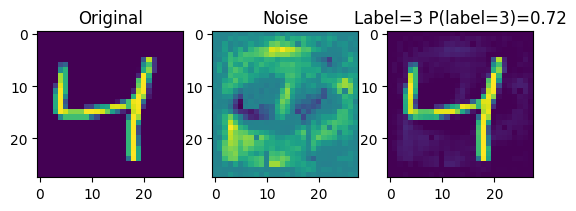

In [ ]:
create_adversarial_example(fc_model, mnist_images[2][0], 3)

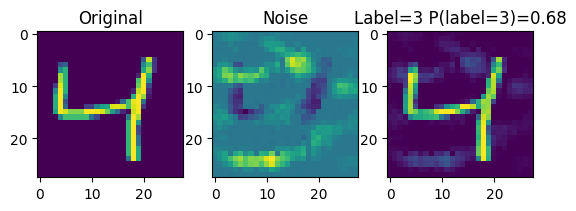

In [ ]:
create_adversarial_example(cnn_model, mnist_images[2][0], 3)

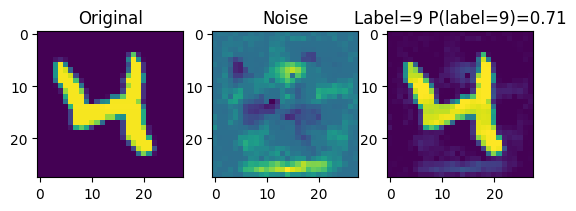

In [ ]:
create_adversarial_example(fc_model, mnist_images[20][0], 9)

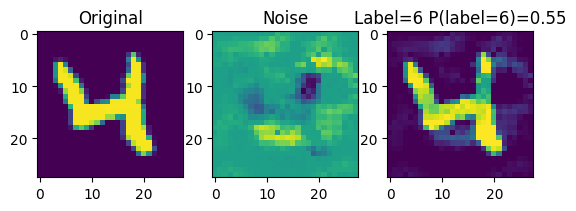

In [ ]:
create_adversarial_example(cnn_model, mnist_images[20][0], 6)